<h1 style="text-align: center; font-family: Arial; font-weight: bold; color:green; font-size:36px;">Sentiment Analysis on Energy in the Republic Ireland and other European Countries</h1>
<p>
    Data are gathered through multiple Reddit Forums related to energy topics in Ireland using the authorized API, adhering to the website's policies and regulations.  
</p>

In [6]:
# Import Libraries
# API Requests
import requests
import json

#Accessing Environment Variables
import os

# Data Manipulation
import pandas as pd
import re

# Visualisation
import plotly.express as px

# Word processors
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from dotenv import load_dotenv
from wordcloud import WordCloud

# Model
from flair.models import TextClassifier

In [7]:
# Install nltk
#!pip install nltk

# Download stopwords and punkt
#nltk.download('punkt')
#nltk.download('stopwords')

#Install wordcloud
#!pip install wordcloud

In [8]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load Credentials

In [10]:
# Load environment variables
load_dotenv()

# Get required credentials 
CLIENT_ID = os.getenv('CLIENT_ID')
CLIENT_SECRET = os.getenv('CLIENT_SECRET')
USERNAME = os.getenv('REDDIT_USERNAME')
PASSWORD = os.getenv('REDDIT_PASSWORD')
USER_AGENT= os.getenv('REDDIT_USERAGENT')

# Check all variables are loaded
if CLIENT_ID and CLIENT_SECRET and USERNAME and PASSWORD:
    print('Credentials Loaded!')
else:
    print('Error loading credentials!')

Credentials Loaded!


### Get Access Token

In [12]:
# Identify authentication method
data = {
    'grant_type': 'password',
    'username': USERNAME,
    'password': PASSWORD
}

# Authentication
auth = requests.auth.HTTPBasicAuth(CLIENT_ID, CLIENT_SECRET)

# Headers
headers = {'User-Agent': USER_AGENT}

# Get access token
res = requests.post('https://www.reddit.com/api/v1/access_token',
                    auth=auth, data=data, headers=headers)

# Check if response is valid
if res.status_code != 200:
    print("Token request failed:", res.text)
    exit()
else: 
    token = res.json()['access_token']

## Data Gathering

In [14]:
# List of all Reddit posts related to energy in Ireland which will be used to extract data
IE_POST_ID =[
    '1g6t908/electricity_bill/',
    '1b3qqxh/electricity_bill/',
    '12yqhv8/can_someone_eli5_why_our_electricity_prices_are/',
    '1exjvob/very_high_electricity_bill/',
    '1cuw7de/insane_electricity_usage/',
    '1k29se6/rise_in_electricity_costs_amid_move_from_fossil/',
    '/1jvvhli/lovely_day_outside_for_65_of_our_electricity_to/',
    '/1gk49ps/blow_for_homeowners_with_solar_panels_as_electric/',
    '1dndzwv/best_energy_provider_to_go_with/',
    '/1h1s73w/irelands_data_centres_turning_to_fossil_fuels/',
    '1ac754l/anyone_with_electric_ireland/',
    '1j07rjd/sse_airtricity_to_hike_electricity_gas_prices/'
]

DE_POST_ID=[
    'qmdxtt/people_of_germany_why_is_your_electricity_cost/',
    'hu6lf8/germany_hits_627_renewables_in_2024_electricity/',
    '18pxe9v/almost_52_of_germanys_gross_electricity/',
    '1d0ab3a/germany_now_has_so_much_solar_power_that_its/',
    '6aqft4/germany_just_smashed_an_energy_record_generating/'
]

HU_POST_ID=[
    '1h52uty/electricity_bill/',
    '/edwfri/paks_nuclear_power_plant_the_first_and_only/',
    '/zoe29z/1400_kwh_electricity_usage_possible_in_one_month/'
]

### Scrape Data using Reddit API

In [34]:
# Set headers
headers = {
    'Authorization': f'bearer {token}',
    'User-Agent': USER_AGENT
}

# Initialize variable to store all scraped data
sentiment_arr = []

# Create a function to store data
append_function = lambda a ,x, y: sentiment_arr.append({'country': a ,'source':x,'comment':str(y)})

# Initialize Regex Pattern to get comments within 'selftext' to 'body'
re_pattern=r'"(?:selftext|body)"\s*:\s*"((?:\\.|[^"\\])*)"'

def collect_data(country, POST_ID):
    # Go through all POST_IDs 
    for _id in POST_ID:
        try:
            # Join URL and POST_ID
            url = f'https://oauth.reddit.com/comments/{_id}'
            print(f'getting data from {url}')
    
            # API call
            response = requests.get(url, headers=headers)
    
            # Check for response if success (200)
            if response.status_code != 200:
                print("Failed to fetch comments:", response.text)
                exit()
            else: 
                pass
                
            # Retrieve all matching patterns
            matches = re.findall(re_pattern, json.dumps(response.json()))  

            # Loop through all scraped data and store
            for match in matches:
              append_function(country, _id, match)
                
        except Exception as e:
            print(f'Error retrieving data from {_id}, error details: {e}')

collect_data('Ireland', IE_POST_ID)
collect_data('Germany', DE_POST_ID)
collect_data('Hungary', HU_POST_ID)

print('Collecting data completed!')

print('Randomly picking data per country.')

# Convert array to dataframe
sentiments_df = pd.DataFrame(sentiment_arr)
sentiments_df

# Randomize selection of data and limit by 500 comments per country 
sentiments_df = sentiments_df.groupby('country').sample(n=500, replace=True, random_state=42).reset_index()
print(sentiments_df.country.value_counts())

print('Process Completed!')

getting data from https://oauth.reddit.com/comments/1g6t908/electricity_bill/
[{"kind": "Listing", "data": {"after": null, "dist": 1, "modhash": null, "geo_filter": "", "children": [{"kind": "t3", "data": {"approved_at_utc": null, "subreddit": "ireland", "selftext": "We moved house in September 2023 and signed up to flogas.  I remember a man coming to take a reading and I also remember submitting a reading.  They said I submitted a reading in August but they have no record of another reading.\n\nWe paid every bill we got but then we got 7 bills in October totalling about \u20ac1,900 in the run up to Christmas.  I thought it was a mistake and range them up but they said it was correct and were adjusting based on the August meter reading submitted.  Why did they not bill us in August?\n\nI can't get my head around it.  I renewed about three weeks ago and they never said anything about backdating billing or monies owed.  Is it legal to backdate billing in such a manner?\n\n\\*\\*edit\\*\"

KeyboardInterrupt: 

## Data Cleaning

In [81]:
# Assign Lemmatizer
lemmatizer = WordNetLemmatizer()

# Set stop words to English
stop_words = set(stopwords.words('english'))

# Create a function to check for characters only
def is_letter_only(word):
    for char in word:
        if not char.isalpha():
            return False
    return True

# Create a function to lemmmatize text
def lemmatize_text(text):
    text_cleaned = ' '.join(lemmatizer.lemmatize(word) for word in text.split() if is_letter_only(word) and word)
    return text_cleaned

# Create a consolidate function to clean string
def custom_preprocessor(text, process=''):
    #Remove URLS
    text = re.sub(r"http\S+|www\S+", "", text)
   
    # Remove special characters
    text = re.sub(r"[^\w\s]", "", text)
   
    # Normalize white spaces
    text = re.sub(r"\s+", " ", text).strip()
   
    #Set all characters to lowercase
    text=text.lower()

    # Check if process='all' -- all steps will be performed in case converting texts to a bag of words
    # This is isolated since the steps below are not necessary for flair analysis
    if process=='all':
        # Remove stop words
        words = word_tokenize(text)
        filtered_text = [word for word in words if word.lower() not in stop_words and word.isalnum()]
        text=lemmatize_text(" ".join(filtered_text))
    else:
        pass
    # Return processed text
    return text

# Test functions
print(f'test: \n\nbefore: {sentiments_df.iloc[2].comment} \n\nafter: {custom_preprocessor(sentiments_df.iloc[2].comment, process='all')}')

test: 

before: If you could produce your own electricity rather than rely on ours that would be nice, sincerely Sweden. 

after: could produce electricity rather rely would nice sincerely sweden


## Transform to Bag of Words

In [84]:
# Use CountVectorizer
vectorizer=CountVectorizer(stop_words='english',
                        max_df = .1, # Ignore words that appear in more than 10% of the document - treat them as too common to be useful
                        max_features = 500) # Top 500 words

# Apply custom cleaning to each comment
cleaned_comments = sentiments_df['comment'].apply(custom_preprocessor, process='all')

# Fit transform Data for vectorizer
X = vectorizer.fit_transform(cleaned_comments)

# Get Feature names
feature_names = vectorizer.get_feature_names_out()

# Revert data back to dataframe
X_df = pd.DataFrame(X.toarray(), columns=feature_names)

X_df

,able,absolute,absolutely,ac,accident,actual,actually,add,adult,ago,...,working,world,worth,wouldnt,wrong,yeah,year,yes,youre,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1497,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Latent Dirichlet Allocation (LDA)

This process will utilize LDA to identify or extract key topics present within the collected data.

In [87]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components = 10,
                                random_state = 123,
                                learning_method = 'batch')
lda_result_topics = lda.fit_transform(X_df)

In [88]:
lda.components_.shape

(10, 500)

### Extract Key Topics from the LDA Result

In [92]:
n_top_words = 5

for topic_idx, topic in enumerate(lda.components_):
    print("Topic %d:" % (topic_idx + 1))
    print(" ".join([feature_names[i]
                    for i in topic.argsort()\
                        [:-n_top_words - 1:-1]]))

Topic 1:
coal time gas germany year
Topic 2:
day month kwh charge tax
Topic 3:
meter electric dont know water
Topic 4:
time going use wind consumption
Topic 5:
germany plant grid reactor cooling
Topic 6:
cost make government people time
Topic 7:
price check meter rate ac
Topic 8:
plant wind solar better need
Topic 9:
storage renewables wind need solar
Topic 10:
pay year reading deleted people


In [98]:
ie_energy = lda_result_topics[:, 5].argsort()[::-1]

for iter_idx, comment_idx in enumerate(ie_energy[:5]):
    print('\n Energy Sentiment #%d:' % (iter_idx + 1))
    print(custom_preprocessor(sentiments_df['comment'][comment_idx]))


 Energy Sentiment #1:
yup this 100 more and more companies dont have to pay the eegumlage that means that the citizens have to pay it the whole eeg in 2013 costs 20 billion 4 billion of that were supposed to come the industry which they dont have to pay anymore half the industrial electricity consumption doesnt pay for it nnthis and the mehrwertsteuer is stupid because you pay taxes on the taxes not cost tax eeg but cost eeg tax

 Energy Sentiment #2:
number of deaths is only slightly lower and what about environmental damage what about exclusion zones that people still cant return to fukushima didnt cause deaths directly but lots of people still cant return to their homes 8 years later

 Energy Sentiment #3:
number of deaths is only slightly lower and what about environmental damage what about exclusion zones that people still cant return to fukushima didnt cause deaths directly but lots of people still cant return to their homes 8 years later

 Energy Sentiment #4:
number of deaths 

### Generate Word Cloud Based on the Top Words

In [101]:
# Get sum of occurrences per word
word_counts = X_df.sum(axis=0) # Convert sparse matrix to array
vocab=feature_names

# Transform to a dataframe and sort values from highest to lowest
word_freq = pd.DataFrame({'word': vocab, 'count': word_counts})
top_words = word_freq.sort_values(by='count', ascending=False)

# Show top 10 words
top_words.head(10)

,word,count
year,year,207
like,like,167
need,need,166
wind,wind,149
plant,plant,148
time,time,146
price,price,145
renewables,renewables,144
meter,meter,143
dont,dont,142


### Generate Word Cloud based on the Top Word Count

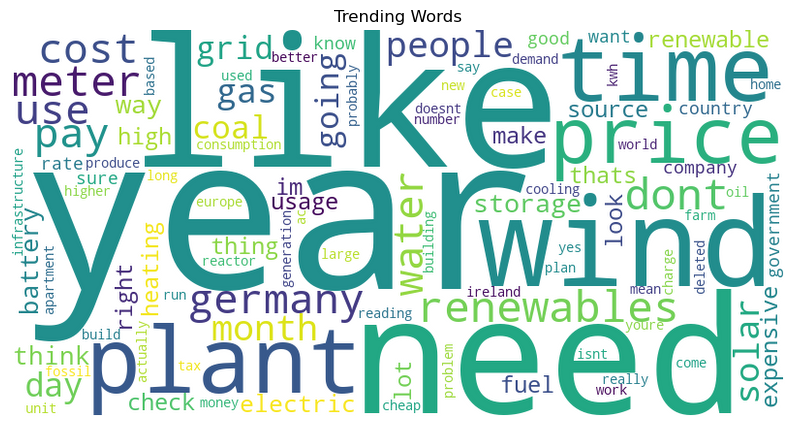

In [104]:
# Generate Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create a dictionary of word and count
word_freq_dict = dict(zip(top_words['word'], top_words['count']))

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',  
    max_words=100  # show only top 100 frequent words
).generate_from_frequencies(word_freq_dict)

# Display
plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation='lanczos')
plt.axis('off')
plt.title('Trending Words')
plt.show()

## Sentiment Analysis using Flair

In [107]:
# Clean data necessary for Flair
sentiments_df['cleaned']=sentiments_df.comment.apply(custom_preprocessor)

# Check length of words, remove rows with comment length below 10 words
sentiments_df=sentiments_df.loc[sentiments_df['cleaned'].apply(lambda x: len(x.split()) > 10)]

In [109]:
# Install Flair
# !pip install flair

In [111]:
# Load text classifier in english
classifier = TextClassifier.load('en-sentiment')

# Import Flair Sentence to process input text
from flair.data import Sentence

# Import accuracy_score to check performance
from sklearn.metrics import accuracy_score

In [112]:
# Create function to check score and provide equivalent sentiment
def format_output_flair(sentence):
    label = sentence.labels[0]
    if label.value == 'POSITIVE' and label.score > 0.7:
        return("Positive")
    elif label.value == 'NEGATIVE' and label.score > 0.7:
        return("Negative")
    else:
        return("Neutral")

# Create a function to analyze text sentiment using Flair
def analyze_flair(text):
    sentence = Sentence(text)
    classifier.predict(sentence)
    score = sentence.labels[0].score
    value = format_output_flair(sentence)
    return score, value

In [113]:
# Analyze data and store it in the dataframe
sentiments_df['flair_score'], sentiments_df['flair_prediction'] = zip(*sentiments_df['cleaned'].apply(analyze_flair))
sentiments_df.head(5)

,index,country,source,comment,cleaned,flair_score,flair_prediction
1,1540,Germany,1d0ab3a/germany_now_has_so_much_solar_power_th...,There is no information on wikipedia that supp...,there is no information on wikipedia that supp...,0.996253,Negative
2,1375,Germany,18pxe9v/almost_52_of_germanys_gross_electricity/,If you could produce your own electricity rath...,if you could produce your own electricity rath...,0.958172,Negative
3,1211,Germany,qmdxtt/people_of_germany_why_is_your_electrici...,This is simply wrong. Germany is a net exporte...,this is simply wrong germany is a net exporter...,0.999675,Negative
4,1176,Germany,qmdxtt/people_of_germany_why_is_your_electrici...,Bad strategic decisions. I could just play tha...,bad strategic decisions i could just play that...,0.997800,Negative
5,1805,Germany,6aqft4/germany_just_smashed_an_energy_record_g...,Doesn't the army have quite a bit of money inv...,doesnt the army have quite a bit of money inve...,0.995618,Negative


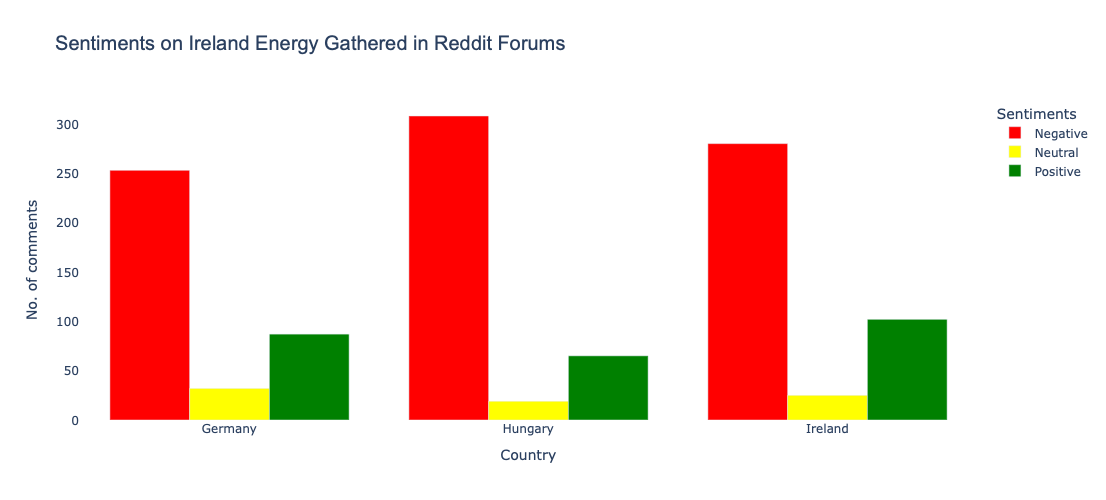

In [114]:
# Define color map
color_map = {
    'Positive': 'green',
    'Negative': 'red',
    'Neutral': 'yellow'
}

grouped_df = sentiments_df.groupby(['country', 'flair_prediction']).size().reset_index(name='count')


# Project Results
fig = px.bar(
    grouped_df,
    x='country', 
    y='count', 
    color='flair_prediction',
    color_discrete_map=color_map,
    labels={
        'count': 'No. of comments',
        'flair_prediction': 'Sentiments',
        'country': 'Country'
    },
    title='Sentiments on Ireland Energy Gathered in Reddit Forums',
    barmode='group'
)


fig.update_layout(
    title_font=dict(size=20, family='Arial'),
    width=900,
    height=500,
    plot_bgcolor='rgba(0,0,0,0)' # this makes background transparent
)

fig.show()

# References


Pandey, P. (2023) The power of NLP with Flair: A comprehensive guide and comparison with other libraries. Medium. Available at: https://medium.com/@pankaj_pandey/the-power-of-nlp-with-flair-a-comprehensive-guide-and-comparison-with-other-libraries-d99875595396 (Accessed: 25 April 2025).

Akbik, A., Bergmann, T., Blythe, D., Rasul, K., Schweter, S. and Vollgraf, R. (2019) FLAIR: An easy-to-use framework for state-of-the-art NLP. Available at: https://github.com/flairNLP/flair (Accessed: 25 April 2025).
